In [1]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("Social_Network_Ads.csv")
print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [3]:
df=df.iloc[:,2:]

In [5]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [4]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Convert to PyTorch tensors
x_train=torch.tensor(x_train,dtype=torch.float32)
x_test=torch.tensor(x_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32).view(-1,1)
y_test=torch.tensor(y_test,dtype=torch.float32).view(-1,1)

In [5]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(2,128)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(128,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,x):
        x=self.relu(self.fc1(x))
        x=self.sigmoid(self.fc2(x))
        return x

In [6]:
model=Model()

In [7]:
criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [9]:
epochs=100
val_acc_list=[]
for epoch in range(epochs):
    outputs=model(x_train)
    loss=criterion(outputs,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        val_outputs=model(x_test)
        predicted=(val_outputs>0.5).float()
        correct=(predicted==y_test).sum().item()
        val_acc=correct/len(y_test)
        val_acc_list.append(val_acc)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Val Accuracy: {val_acc:.4f}")

Epoch 1/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 2/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 3/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 4/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 5/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 6/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 7/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 8/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 9/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 10/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 11/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 12/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 13/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 14/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 15/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 16/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 17/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 18/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 19/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 20/100, Loss: 64.0625, Val Accuracy: 0.3500
Epoch 21/

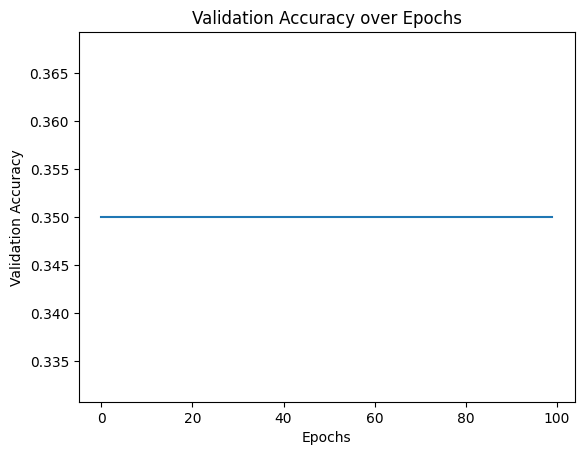

In [10]:
plt.plot(val_acc_list)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy over Epochs")
plt.show()